# Rice Price Prediction in Sri Lanka

**Programming for Artificial Intelligence**

## 1. Problem Definition

**Problem:** Rice is Sri Lanka's staple food, and its retail price has become highly
unstable in recent years — especially during the 2022 economic crisis, when prices
more than doubled in a short period. This project builds a simple model to predict
the monthly retail rice price in Sri Lanka using related economic indicators
(producer prices, exchange rate, fuel price, and money supply).

**Why this matters in Sri Lanka:** Rice price directly affects household food
security and cost of living. Sudden price spikes hit low-income households the
hardest. Understanding which economic factors move rice prices can help consumers,
policymakers, and farmers anticipate changes.

**Who benefits:** Consumers (budgeting), farmers/traders (pricing decisions), and
policymakers (early warning of price shocks).

**Expected output:** A trained model that predicts the monthly retail rice price
from economic indicators, plus visualizations showing how price has changed over
time and which factors relate to it most strongly.

**Dataset source:** *SriOryzia: Multivariate Rice Price Forecasting* dataset,
by luqmanrumaiz, Kaggle —
https://www.kaggle.com/datasets/luqmanrumaiz/srioryzia-multivariate-rice-price-forecasting
(324 monthly records, January 1996 – December 2022. Producer prices from
Anuradhapura, Kurunegala, and Polonnaruwa; also includes exchange rate, fuel price,
paddy production, and money supply aggregates M0/M1/M2/M2B.)


## 2. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# used for the prediction model at the end
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# Folder in Google Drive where rice_price_data.csv is stored
DRIVE_FOLDER = "/content/drive/MyDrive/Colab Notebooks/MSc_Assignments"


Mounted at /content/drive


In [ ]:
def load_data(file_path):
    """Loads the rice price CSV file. Returns a DataFrame, or None if loading fails."""
    try:
        data = pd.read_csv(file_path)
        print(f"Loaded '{file_path}' successfully.")
        return data
    except FileNotFoundError:
        print(f"Error: file not found at '{file_path}'.")
        return None
    except Exception as e:
        print(f"Error while loading file: {e}")
        return None


df = load_data(f"{DRIVE_FOLDER}/rice_price_data.csv")
df.head()


Loaded '/content/drive/MyDrive/Colab Notebooks/MSc_Assignments/rice_price_data.csv' successfully.


,date,price,anuradhapura_producer_price,kurunegala_producer_price,polonnaruwa_producer_price,production,production_total,exchange_rate,fuel_price,m0,m2,m1,m2b
0,1996-01-01,18.07,7.75,7.90,8.18,1333.6,2065.1,53.685,12.4,77071,228090,73783,260481
1,1996-02-01,18.70,8.17,8.26,8.76,1333.6,2065.1,53.685,12.4,79586,234199,77440,269496
2,1996-03-01,18.49,7.95,7.85,7.99,1333.6,2065.1,53.685,12.4,82915,239178,81796,272552
3,1996-04-01,18.52,8.25,8.01,8.29,1333.6,2065.1,54.735,12.4,80873,241893,79478,278425
4,1996-05-01,19.02,8.38,8.50,8.34,731.5,2065.1,54.950,12.4,83410,242072,76620,277365


In [ ]:
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Column names:", list(df.columns))

Number of records: 324
Number of columns: 13

Column names: ['date', 'price', 'anuradhapura_producer_price', 'kurunegala_producer_price', 'polonnaruwa_producer_price', 'production', 'production_total', 'exchange_rate', 'fuel_price', 'm0', 'm2', 'm1', 'm2b']


In [ ]:
df.dtypes

,0
date,object
price,float64
anuradhapura_producer_price,float64
kurunegala_producer_price,float64
polonnaruwa_producer_price,float64
production,float64
production_total,float64
exchange_rate,float64
fuel_price,float64
m0,int64


In [ ]:
df.describe()

,price,anuradhapura_producer_price,kurunegala_producer_price,polonnaruwa_producer_price,production,production_total,exchange_rate,fuel_price,m0,m2,m1,m2b
count,320.000000,312.000000,314.000000,304.000000,324.000000,324.000000,324.000000,324.000000,3.240000e+02,3.240000e+02,3.240000e+02,3.240000e+02
mean,61.460844,27.760449,28.377529,28.570263,1831.638627,3521.530556,124.167160,77.366358,4.441924e+05,2.754054e+06,4.475535e+05,3.119900e+06
std,41.523549,21.046822,21.493946,22.532763,636.826804,867.006390,55.706235,69.052940,3.724932e+05,2.890803e+06,3.822088e+05,3.229546e+06
min,18.070000,7.750000,7.810000,7.870000,731.500000,2065.100000,53.685000,12.400000,7.182800e+04,2.280900e+05,7.378300e+04,2.604810e+05
25%,28.787500,12.195000,12.080000,12.360000,1333.600000,2858.800000,96.187500,30.000000,1.213460e+05,4.924885e+05,1.293800e+05,6.044058e+05
50%,59.940000,25.460000,26.545000,25.705000,1774.500000,3380.800000,111.150000,73.000000,2.802080e+05,1.396338e+06,2.814140e+05,1.664421e+06
75%,78.655000,35.167500,35.572500,35.892500,2135.600000,4300.600000,144.895000,104.000000,7.437918e+05,4.215070e+06,7.077622e+05,4.741758e+06
max,250.070000,131.550000,141.950000,138.200000,3196.750000,5149.600000,368.500000,460.000000,1.481805e+06,1.049705e+07,1.635133e+06,1.228964e+07


**Target variable:** `price` — the average monthly retail rice price (LKR/kg).
**Main features:** producer prices from three districts, exchange rate, fuel price,
paddy production, and money supply figures (m0, m1, m2, m2b).

## 3. Data Preparation

Steps:
1. Check for missing values and duplicate rows
2. Fill missing values (numeric columns only, using each column's median)
3. Convert `date` to a proper datetime type, then extract `year` for later use
4. Confirm the dataset is clean

A small function + loop is used to fill missing values column by column, so the
logic is explicit rather than hidden inside a single library call.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
date                            0
price                           4
anuradhapura_producer_price    12
kurunegala_producer_price      10
polonnaruwa_producer_price     20
production                      0
production_total                0
exchange_rate                   0
fuel_price                      0
m0                              0
m2                              0
m1                              0
m2b                             0
dtype: int64

Duplicate rows: 0


In [ ]:
def fill_missing_with_median(data, columns):
    """Fills missing values in the given numeric columns using each column's median."""
    for col in columns:
        if data[col].isnull().sum() > 0:          # only touch columns that actually have gaps
            median_value = data[col].median()
            data[col] = data[col].fillna(median_value)
            print(f"Filled {col}: missing values replaced with median ({median_value:.2f})")
    return data


numeric_cols = df.select_dtypes(include="number").columns.tolist()
df = fill_missing_with_median(df, numeric_cols)

print("\nRemaining missing values:", df.isnull().sum().sum())


Filled price: missing values replaced with median (59.94)
Filled anuradhapura_producer_price: missing values replaced with median (25.46)
Filled kurunegala_producer_price: missing values replaced with median (26.55)
Filled polonnaruwa_producer_price: missing values replaced with median (25.70)

Remaining missing values: 0


In [ ]:
df = df.drop_duplicates()

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (324, 14)


,date,price,anuradhapura_producer_price,kurunegala_producer_price,polonnaruwa_producer_price,production,production_total,exchange_rate,fuel_price,m0,m2,m1,m2b,year
0,1996-01-01,18.07,7.75,7.90,8.18,1333.6,2065.1,53.685,12.4,77071,228090,73783,260481,1996
1,1996-02-01,18.70,8.17,8.26,8.76,1333.6,2065.1,53.685,12.4,79586,234199,77440,269496,1996
2,1996-03-01,18.49,7.95,7.85,7.99,1333.6,2065.1,53.685,12.4,82915,239178,81796,272552,1996
3,1996-04-01,18.52,8.25,8.01,8.29,1333.6,2065.1,54.735,12.4,80873,241893,79478,278425,1996
4,1996-05-01,19.02,8.38,8.50,8.34,731.5,2065.1,54.950,12.4,83410,242072,76620,277365,1996


## 4. Data Exploration and Visualisation

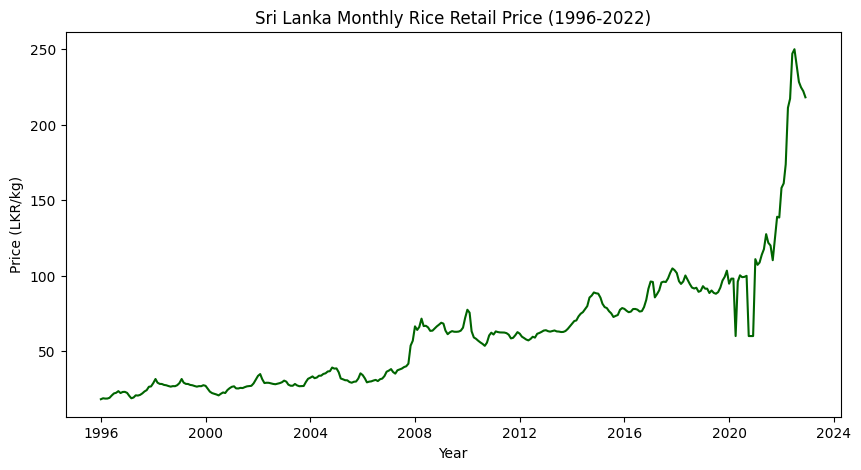

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["price"], color="darkgreen")
plt.title("Sri Lanka Monthly Rice Retail Price (1996-2022)")
plt.xlabel("Year")
plt.ylabel("Price (LKR/kg)")
plt.show()

# Interpretation: price stayed fairly low and stable until around 2020,
# then rose sharply during the 2021-2022 economic crisis.

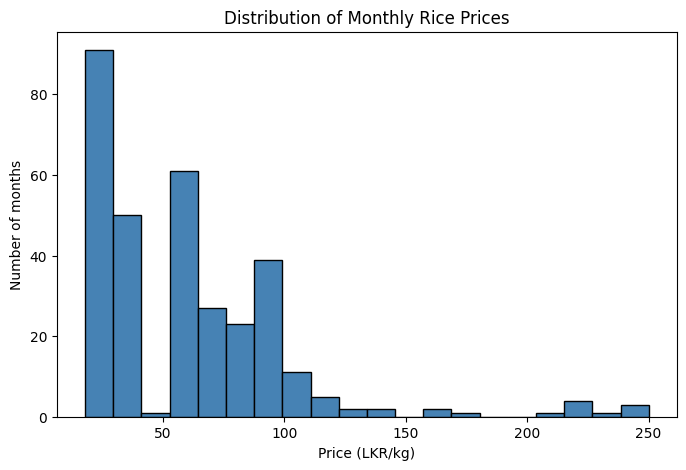

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution of Monthly Rice Prices")
plt.xlabel("Price (LKR/kg)")
plt.ylabel("Number of months")
plt.show()

# Interpretation: most months fall in the lower price range, with a smaller
# number of months reaching very high prices - the 2022 price spike.

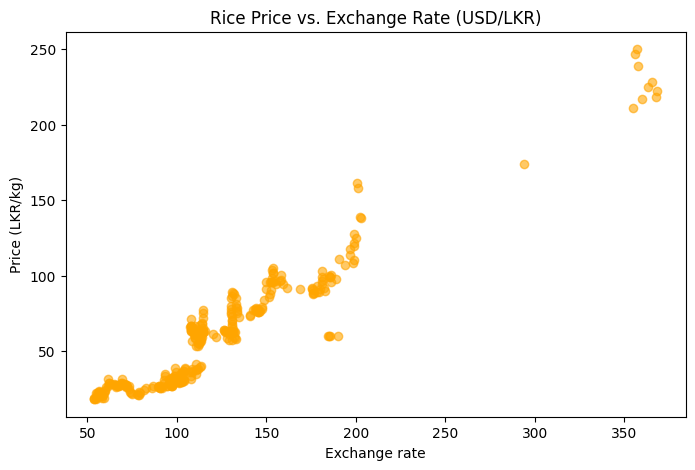

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["exchange_rate"], df["price"], alpha=0.6, color="orange")
plt.title("Rice Price vs. Exchange Rate (USD/LKR)")
plt.xlabel("Exchange rate")
plt.ylabel("Price (LKR/kg)")
plt.show()

# Interpretation: higher exchange rate (weaker rupee) is associated with
# higher rice prices, which makes sense since fuel and fertiliser are imported.

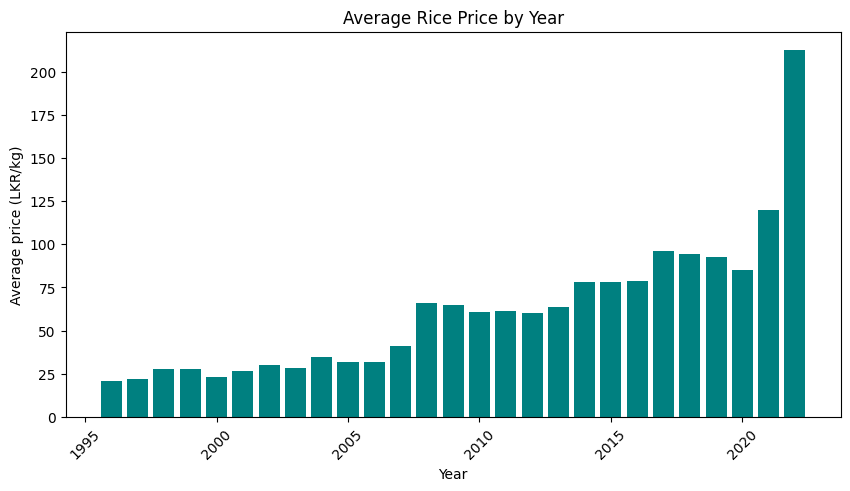

In [ ]:
yearly_avg = df.groupby("year")["price"].mean()

plt.figure(figsize=(10, 5))
plt.bar(yearly_avg.index, yearly_avg.values, color="teal")
plt.title("Average Rice Price by Year")
plt.xlabel("Year")
plt.ylabel("Average price (LKR/kg)")
plt.xticks(rotation=45)
plt.show()

# Interpretation: a clear year-on-year rise, with the steepest jump in 2022.

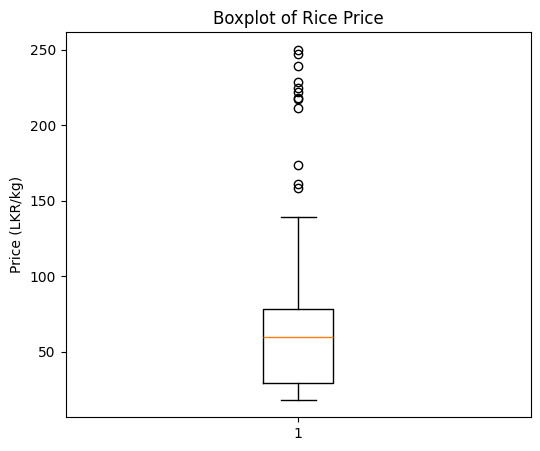

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["price"], vert=True)
plt.title("Boxplot of Rice Price")
plt.ylabel("Price (LKR/kg)")
plt.show()

# Interpretation: the box shows most prices are clustered in the lower half,
# with several high outlier months (matching the 2022 spike seen above).

## 5. Solution Development — Predicting Rice Price

A simple **Linear Regression** model is used to predict `price` from the other
economic indicators. This keeps the solution basic and easy to explain, as required
by the assignment, while still producing a meaningful prediction.

In [ ]:
feature_cols = ["anuradhapura_producer_price", "kurunegala_producer_price",
                "polonnaruwa_producer_price", "exchange_rate", "fuel_price",
                "m0", "m1", "m2", "m2b"]

X = df[feature_cols]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 259
Testing rows: 65


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} LKR/kg")
print(f"R-squared: {r2:.3f}")

Mean Absolute Error: 4.01 LKR/kg
R-squared: 0.972


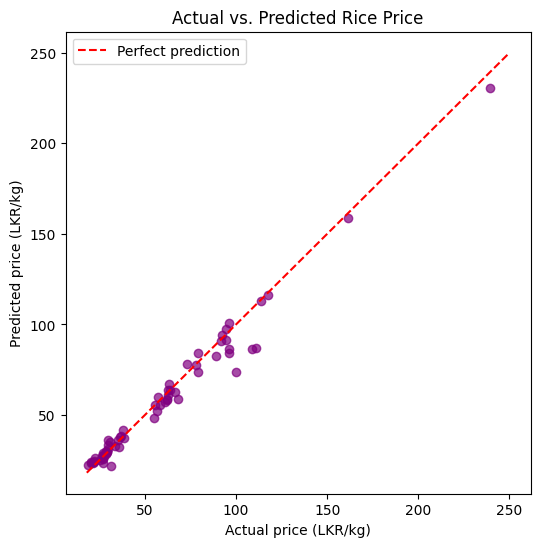

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="purple")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="Perfect prediction")
plt.xlabel("Actual price (LKR/kg)")
plt.ylabel("Predicted price (LKR/kg)")
plt.title("Actual vs. Predicted Rice Price")
plt.legend()
plt.show()

In [ ]:
def check_prediction_quality(r2_value):
    """A simple conditional check to describe how good the model's fit is."""
    if r2_value >= 0.9:
        return "Excellent fit"
    elif r2_value >= 0.7:
        return "Good fit"
    elif r2_value >= 0.5:
        return "Moderate fit"
    else:
        return "Weak fit - model needs improvement"


print("Model quality:", check_prediction_quality(r2))


Model quality: Excellent fit
